# XGBoost from Scratch

Gradient boosting builds an ensemble of regression trees **one at a time**. Each new tree is fitted
to the errors the ensemble has made so far, and its output is added to the running prediction. The
XGBoost formulation of this uses a **second-order** approximation of the loss, which is what gives
it a closed-form leaf weight, an explicit split-gain formula, and a built-in pruning rule.

The raw prediction for a point after $t$ rounds is a sum of tree outputs:

$$F_t(x) = F_{t-1}(x) + \eta\, f_t(x)$$

$F$ lives on the log-odds scale and is turned into a probability by the logistic link:

$$p = \sigma(F) = \frac{1}{1 + e^{-F}}$$

The loss being minimised is binary log loss:

$$l(y, p) = -\left[\, y \log p + (1-y)\log(1-p) \,\right]$$

$\eta$ is the learning rate. It shrinks every tree's contribution, so no single tree can move the
prediction far. Small $\eta$ needs more rounds but usually reaches a lower minimum, because the
ensemble approaches the fit in many small steps instead of a few large ones that overshoot.

## Contrast with Random Forest

A random forest **bags**: it builds $T$ trees independently and in parallel, each on a bootstrap
sample, then averages them. Averaging independent, individually-overfit trees cancels their
uncorrelated errors, so bagging reduces **variance**. Adding more trees to a forest never makes it
worse - the average just gets more stable.

Boosting builds trees **sequentially**, and each tree is fitted specifically to what the previous
ones got wrong. That systematically removes error the ensemble is unable to represent, so boosting
reduces **bias**. The cost is that nothing stops it: given enough rounds the ensemble keeps driving
training loss towards zero and starts fitting the noise in the training set. This is why the number
of boosting rounds is itself a hyperparameter that has to be chosen, while a forest's tree count
does not. Both behaviours show up in the charts below.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import style
from ucimlrepo import fetch_ucirepo

style.use('ggplot')

BLUE = '#2a78d6'
ORANGE = '#eb6834'
AQUA = '#1baf7a'

np.random.seed(42)

## Loading the data

The cell downloads UCI Heart Disease. `features` holds 13 clinical measurements and `targets` holds
`num`, a severity grade from 0 to 4.

`ca` has 4 missing values and `thal` has 2. The features and the target are concatenated into
`joined` **before** dropping those rows, so that removing a row removes its label as well and the
two stay aligned. That leaves 297 rows from the original 303.

`y` binarises the target: `num > 0` becomes 1 for presence of disease and 0 for absence, collapsing
the four severity grades into one positive class.

Trees split on thresholds of the form $x_j \le v$, and any monotone rescaling of a column moves the
thresholds by the same amount without changing which rows land on which side. So no scaling or
standardisation is applied.

In [2]:
heart = fetch_ucirepo(id=45)

features = heart.data.features
targets = heart.data.targets
feature_names = list(features.columns)

# join before dropping so rows and labels stay aligned
joined = pd.concat([features, targets], axis=1).dropna()

X = joined[feature_names].values.astype(float)
y = (joined['num'].values > 0).astype(int)

print('rows after dropping missing:', X.shape[0], 'of', features.shape[0])
print('features:', X.shape[1])
print('absence (0):', (y == 0).sum(), ' presence (1):', (y == 1).sum())
print()
print('columns:', feature_names)

rows after dropping missing: 297 of 303
features: 13
absence (0): 160  presence (1): 137

columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


## Train / test split

`np.random.permutation` shuffles the row indices under the seed set above, then the first 25% become
the test set and the rest the training set. Writing it out this way keeps the whole notebook to
numpy and makes the split reproducible from the seed alone.

The class balance in each half is printed so it is clear neither side ended up lopsided.

In [3]:
idx = np.random.permutation(len(X))
n_test = int(0.25 * len(X))

test_idx = idx[:n_test]
train_idx = idx[n_test:]

X_train, y_train = X[train_idx], y[train_idx]
X_test, y_test = X[test_idx], y[test_idx]

print('train:', X_train.shape[0], 'rows, presence rate', round(y_train.mean(), 3))
print('test: ', X_test.shape[0], 'rows, presence rate', round(y_test.mean(), 3))

train: 223 rows, presence rate 0.471
test:  74 rows, presence rate 0.432


## The loss, and its first two derivatives

`sigmoid` maps a raw score to a probability and `log_loss` averages the binary log loss over a set
of points, clipping the probabilities away from 0 and 1 so the logarithm stays finite.

Everything the trees are fitted to comes from differentiating the log loss with respect to the raw
prediction $F$, not with respect to $p$. Substituting $p = \sigma(F)$ into the log loss gives

$$l(y, F) = \log\!\left(1 + e^{F}\right) - yF$$

and differentiating twice, using $\sigma'(F) = \sigma(F)\,(1 - \sigma(F))$:

$$g_i = \frac{\partial l}{\partial F_i} = p_i - y_i
\qquad\qquad
h_i = \frac{\partial^2 l}{\partial F_i^2} = p_i\,(1 - p_i)$$

The gradient $g_i$ is just the residual: how far the current probability is from the label. The
hessian $h_i$ is largest at $p = 0.5$ and shrinks towards zero as the prediction becomes confident,
so it acts as a per-point weight - points the ensemble is already sure about carry little influence
over where the next tree splits.

In [4]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))


def log_loss(y, p):
    p = np.clip(p, 1e-12, 1 - 1e-12)
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))


def gradients(y, F):
    p = sigmoid(F)
    return p - y, p * (1 - p)

## Where the leaf weight, the similarity score and the split gain come from

This derivation is the whole of XGBoost; the code below is a direct transcription of it.

**The regularised objective.** The ensemble is scored not only on how well it fits but on how
complicated its trees are:

$$\mathcal{L} = \sum_i l\!\left(y_i, \hat{y}_i\right) + \sum_k \Omega\!\left(f_k\right)
\qquad\text{where}\qquad
\Omega(f) = \gamma T + \tfrac{1}{2}\lambda \sum_{j=1}^{T} w_j^2$$

$T$ is the number of leaves in a tree and $w_j$ is the value sitting in leaf $j$. So $\gamma$ charges
a fixed price per leaf, and $\lambda$ penalises large leaf values.

**The second-order expansion.** At round $t$ the predictions $F_{t-1}$ are fixed and we are choosing
one new tree $f_t$. Taylor-expanding the loss around $F_{t-1}$ to second order, and dropping the
constant term $l(y_i, F_{t-1})$ which does not depend on $f_t$:

$$\mathcal{L}^{(t)} \simeq \sum_i \left[\, g_i\, f_t(x_i) + \tfrac{1}{2} h_i\, f_t(x_i)^2 \,\right] + \Omega(f_t)$$

**Fixing the structure and solving for the leaves.** A tree is a piecewise-constant function: every
point in leaf $j$ gets the same output $w_j$. So if the tree's structure is held fixed, the sum over
points can be regrouped as a sum over leaves, where $I_j$ is the set of points landing in leaf $j$.
Writing $G_j = \sum_{i \in I_j} g_i$ and $H_j = \sum_{i \in I_j} h_i$:

$$\mathcal{L}^{(t)} = \sum_{j=1}^{T} \left[\, G_j w_j + \tfrac{1}{2}\left(H_j + \lambda\right) w_j^2 \,\right] + \gamma T$$

Each leaf now appears in its own independent term, and each term is a quadratic in $w_j$ opening
upwards. Setting the derivative to zero:

$$\frac{\partial \mathcal{L}^{(t)}}{\partial w_j} = G_j + \left(H_j + \lambda\right) w_j = 0$$

$$\boxed{\;w_j^{*} = -\frac{G_j}{H_j + \lambda} = -\frac{\sum_{i \in I_j} g_i}{\sum_{i \in I_j} h_i + \lambda}\;}$$

This is `leaf_weight` in the code. Note what $\lambda$ does: it only ever appears added to $H_j$ in a
denominator, so it drags every leaf weight towards zero, and it bites hardest on leaves with few
points or with small hessians.

**The similarity score.** Substituting $w_j^*$ back into the leaf's term gives its contribution to
the objective, $-\tfrac{1}{2} G_j^2 / (H_j + \lambda)$. Dropping the sign and the half, the quantity
that a node is worth is

$$\text{score} = \frac{\left(\sum_{i \in I} g_i\right)^2}{\sum_{i \in I} h_i + \lambda}$$

This is `similarity`. It is large when the gradients in the node point the same way and so add up
rather than cancel - which is exactly what "these points want the same correction" means.

**The split gain.** Splitting a node into $L$ and $R$ replaces one leaf with two, so it changes the
objective by the two children's scores minus the parent's, and costs one extra leaf at price
$\gamma$:

$$\text{Gain} = \tfrac{1}{2}\left[\frac{G_L^2}{H_L + \lambda} + \frac{G_R^2}{H_R + \lambda} - \frac{(G_L + G_R)^2}{H_L + H_R + \lambda}\right] - \gamma$$

The tree searches every feature and every threshold for the split maximising this.

**Pruning.** The bracketed term is not automatically positive once $\lambda > 0$, and even when it is
positive it may not clear $\gamma$. A split whose gain comes out negative is not taken, and the node
stays a leaf. So $\gamma$ is a direct, explicit limit on tree size that operates independently of
`max_depth`. The counts of splits rejected for each reason are tracked and reported below.

## The Regression_Tree class

This is the tree that gets fitted once per boosting round. It is fitted to `g` and `h` - the
gradients and hessians - rather than to labels, and its leaves hold real-valued corrections rather
than class votes.

- `leaf_weight` and `similarity` are the two boxed formulas above.
- `fit` zeroes the bookkeeping counters and calls `build` on the root.
- `build` is recursive. It first computes what the node would be worth as a leaf, and returns
  immediately if it has hit `max_depth` or has fewer than two points.
- The split search sorts each column once with `np.argsort`, then takes `np.cumsum` of the sorted
  gradients and hessians. Position $k$ of those cumulative sums is $G_L$ and $H_L$ for the split
  just after the $k$-th sorted point, and $G_R = G - G_L$, so every threshold on a feature is
  evaluated in one vectorised pass instead of a loop.
- `cut` keeps only positions where consecutive sorted values actually differ, since splitting
  between two identical values would put them on opposite sides of a threshold they both satisfy.
- `raw` is the gain **before** $\gamma$ is subtracted, kept separate so the counters can tell apart
  a split that was genuinely bad from one that was merely not good enough to pay for itself.
- `heavy` enforces `min_child_weight`: a child whose summed hessian is below it is not allowed,
  which stops the tree isolating a handful of already-confident points.
- If no candidate survives, or the best surviving gain is not positive, the node is returned as a
  leaf. Otherwise the rows are partitioned and `build` recurses on each side.
- `predict` walks each row down the tree from the root and returns the weight of the leaf it lands
  in.

In [5]:
class Regression_Tree:
    def __init__(self, max_depth=3, lambda_=1.0, gamma=0.0, min_child_weight=1.0):
        self.max_depth = max_depth
        self.lambda_ = lambda_
        self.gamma = gamma
        self.min_child_weight = min_child_weight

    def leaf_weight(self, g, h):
        return -g.sum() / (h.sum() + self.lambda_)

    def similarity(self, g, h):
        return (g.sum() ** 2) / (h.sum() + self.lambda_)

    def fit(self, X, g, h):
        self.n_features = X.shape[1]
        self.gain_by_feature = np.zeros(self.n_features)
        self.n_candidates = 0
        self.n_negative_gain = 0
        self.n_gamma_rejected = 0
        self.n_child_weight_rejected = 0
        self.nodes_split = 0
        self.nodes_stopped_by_gamma = 0
        self.root = self.build(X, g, h, 0)
        return self

    def build(self, X, g, h, depth):
        node = {'leaf': True, 'weight': self.leaf_weight(g, h), 'n': len(g)}
        if depth >= self.max_depth or len(g) < 2:
            return node

        parent = self.similarity(g, h)
        best_gain = -np.inf
        best = None
        best_raw = 0.0

        for j in range(self.n_features):
            col = X[:, j]
            order = np.argsort(col, kind='mergesort')
            cs = col[order]
            gs = np.cumsum(g[order])
            hs = np.cumsum(h[order])
            G, H = gs[-1], hs[-1]

            # split positions only between distinct consecutive values
            cut = np.nonzero(cs[:-1] < cs[1:])[0]
            if len(cut) == 0:
                continue

            GL, HL = gs[cut], hs[cut]
            GR, HR = G - GL, H - HL

            # gain before the gamma penalty
            raw = 0.5 * (GL ** 2 / (HL + self.lambda_)
                         + GR ** 2 / (HR + self.lambda_) - parent)
            heavy = (HL >= self.min_child_weight) & (HR >= self.min_child_weight)

            self.n_candidates += len(cut)
            self.n_child_weight_rejected += int((~heavy).sum())
            self.n_negative_gain += int((heavy & (raw < 0)).sum())
            self.n_gamma_rejected += int((heavy & (raw >= 0) & (raw - self.gamma <= 0)).sum())

            gain = np.where(heavy, raw - self.gamma, -np.inf)
            k = int(np.argmax(gain))
            if gain[k] > best_gain:
                best_gain = float(gain[k])
                best_raw = float(raw[k])
                best = (j, 0.5 * (cs[cut[k]] + cs[cut[k] + 1]))

        if best is None or best_gain <= 0:
            if best is not None and best_raw > 0:
                self.nodes_stopped_by_gamma += 1
            return node

        j, threshold = best
        left = X[:, j] <= threshold
        right = ~left
        self.nodes_split += 1
        self.gain_by_feature[j] += best_gain

        return {'leaf': False, 'feature': j, 'threshold': threshold,
                'gain': best_gain, 'n': len(g),
                'left': self.build(X[left], g[left], h[left], depth + 1),
                'right': self.build(X[right], g[right], h[right], depth + 1)}

    def predict(self, X):
        out = np.empty(len(X))
        for i in range(len(X)):
            node = self.root
            while not node['leaf']:
                if X[i, node['feature']] <= node['threshold']:
                    node = node['left']
                else:
                    node = node['right']
            out[i] = node['weight']
        return out

## The XGBoost class

`fit` runs the boosting loop.

`F0` is the constant starting prediction: the log-odds of the training base rate,
$F_0 = \log\!\frac{\bar{y}}{1 - \bar{y}}$. This is the raw score whose sigmoid is exactly the
proportion of positives, so before any tree exists the model already predicts the base rate, which
is the best a constant can do.

Each round then:

1. converts the current raw scores to probabilities and computes `g` and `h`;
2. fits a fresh `Regression_Tree` to those gradients;
3. updates the scores with $F \leftarrow F + \eta\, f_t(x)$.

The per-round loss and accuracy are recorded for both splits so the curves can be drawn, and the
tree's counters are accumulated onto the model.

`raw_predict` takes an `n_rounds` argument so the ensemble can be evaluated **truncated** to its
first $n$ trees. That is what makes it possible to report the model at its best round without
refitting. `predict_proba` applies the sigmoid and `predict` thresholds at 0.5.

In [6]:
class XGBoost:
    def __init__(self, n_rounds=100, learning_rate=0.3, max_depth=3,
                 lambda_=1.0, gamma=0.0, min_child_weight=1.0):
        self.n_rounds = n_rounds
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.lambda_ = lambda_
        self.gamma = gamma
        self.min_child_weight = min_child_weight

    def fit(self, X, y, X_val=None, y_val=None):
        self.trees = []

        # constant start: log-odds of the base rate
        base = np.clip(y.mean(), 1e-6, 1 - 1e-6)
        self.F0 = np.log(base / (1 - base))

        F = np.full(len(y), self.F0)
        has_val = X_val is not None
        F_val = np.full(len(y_val), self.F0) if has_val else None

        self.train_loss, self.test_loss = [], []
        self.train_acc, self.test_acc = [], []
        self.gain_by_feature = np.zeros(X.shape[1])
        self.n_candidates = 0
        self.n_negative_gain = 0
        self.n_gamma_rejected = 0
        self.n_child_weight_rejected = 0
        self.nodes_split = 0
        self.nodes_stopped_by_gamma = 0

        for t in range(self.n_rounds):
            g, h = gradients(y, F)

            tree = Regression_Tree(self.max_depth, self.lambda_,
                                   self.gamma, self.min_child_weight)
            tree.fit(X, g, h)
            self.trees.append(tree)

            self.gain_by_feature += tree.gain_by_feature
            self.n_candidates += tree.n_candidates
            self.n_negative_gain += tree.n_negative_gain
            self.n_gamma_rejected += tree.n_gamma_rejected
            self.n_child_weight_rejected += tree.n_child_weight_rejected
            self.nodes_split += tree.nodes_split
            self.nodes_stopped_by_gamma += tree.nodes_stopped_by_gamma

            F = F + self.learning_rate * tree.predict(X)
            p = sigmoid(F)
            self.train_loss.append(log_loss(y, p))
            self.train_acc.append((((p >= 0.5).astype(int)) == y).mean())

            if has_val:
                F_val = F_val + self.learning_rate * tree.predict(X_val)
                p_val = sigmoid(F_val)
                self.test_loss.append(log_loss(y_val, p_val))
                self.test_acc.append((((p_val >= 0.5).astype(int)) == y_val).mean())

        self.train_loss = np.array(self.train_loss)
        self.test_loss = np.array(self.test_loss)
        self.train_acc = np.array(self.train_acc)
        self.test_acc = np.array(self.test_acc)
        return self

    def raw_predict(self, X, n_rounds=None):
        n = len(self.trees) if n_rounds is None else n_rounds
        F = np.full(len(X), self.F0)
        for tree in self.trees[:n]:
            F = F + self.learning_rate * tree.predict(X)
        return F

    def predict_proba(self, X, n_rounds=None):
        return sigmoid(self.raw_predict(X, n_rounds))

    def predict(self, X, n_rounds=None):
        return (self.predict_proba(X, n_rounds) >= 0.5).astype(int)

## Training

The cell fits 300 rounds with $\eta = 0.1$, depth-3 trees, $\lambda = 1$, $\gamma = 0.05$ and
`min_child_weight` 1. 300 rounds is deliberately more than the model needs, so that the point where
it starts overfitting is inside the chart rather than off the right-hand edge.

`best_round` is the round at which test log loss is lowest. It is found by `argmin` over the
recorded test losses, so it is the number of trees the truncated ensemble should use.

In [7]:
import time

t0 = time.time()

model = XGBoost(n_rounds=300, learning_rate=0.1, max_depth=3,
                lambda_=1.0, gamma=0.05, min_child_weight=1.0)
model.fit(X_train, y_train, X_test, y_test)

fit_time = time.time() - t0

best_round = int(np.argmin(model.test_loss)) + 1

print('fitted', len(model.trees), 'trees in', round(fit_time, 2), 'seconds')
print('F0 =', round(model.F0, 4), '-> base probability', round(sigmoid(model.F0), 4))
print()
print('best round (lowest test log loss):', best_round)
print('  test log loss :', round(model.test_loss[best_round - 1], 4))
print('  test accuracy :', round(model.test_acc[best_round - 1], 4))
print('  train log loss:', round(model.train_loss[best_round - 1], 4))
print('  train accuracy:', round(model.train_acc[best_round - 1], 4))
print()
print('after all 300 rounds:')
print('  test log loss :', round(model.test_loss[-1], 4))
print('  test accuracy :', round(model.test_acc[-1], 4))
print('  train log loss:', round(model.train_loss[-1], 4))
print('  train accuracy:', round(model.train_acc[-1], 4))

fitted 300 trees in 0.3 seconds
F0 = -0.1167 -> base probability 0.4709

best round (lowest test log loss): 65
  test log loss : 0.3641
  test accuracy : 0.8243
  train log loss: 0.1748
  train accuracy: 0.9596

after all 300 rounds:
  test log loss : 0.4107
  test accuracy : 0.8108
  train log loss: 0.0756
  train accuracy: 0.9955


## Train and test log loss per round

The chart plots both losses against the boosting round on the same axes, with a vertical line at
`best_round`.

This is the signature of boosting. Training loss falls monotonically and keeps falling, because
every additional tree is fitted to whatever training error is left and there is always some left to
fit. Test loss falls with it at first, while the trees are picking up real structure, then reaches a
minimum and turns upward, because the trees after that point are fitting noise specific to the
training rows.

A random forest does not do this. Its trees are independent, so adding more only averages away more
variance and the test curve flattens rather than rising. In boosting the number of rounds is a
capacity knob and has to be chosen.

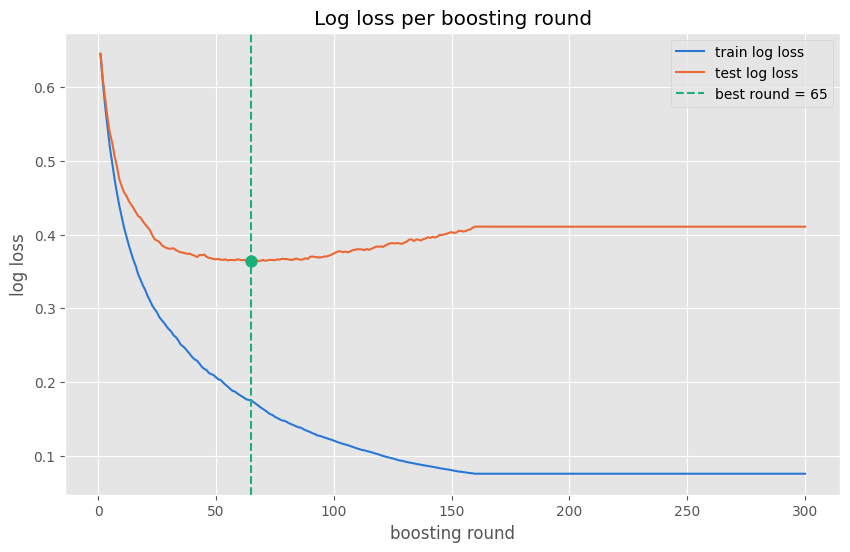

train loss falls from 0.645 to 0.0756
test loss bottoms at 0.3641 on round 65 then rises to 0.4107


In [8]:
rounds = np.arange(1, len(model.train_loss) + 1)

plt.figure(figsize=(10, 6))
plt.plot(rounds, model.train_loss, color=BLUE, label='train log loss')
plt.plot(rounds, model.test_loss, color=ORANGE, label='test log loss')
plt.axvline(best_round, color=AQUA, linestyle='--',
            label=f'best round = {best_round}')
plt.scatter([best_round], [model.test_loss[best_round - 1]],
            color=AQUA, s=70, zorder=5)
plt.title('Log loss per boosting round')
plt.xlabel('boosting round')
plt.ylabel('log loss')
plt.legend()
plt.show()

print('train loss falls from', round(model.train_loss[0], 4),
      'to', round(model.train_loss[-1], 4))
print('test loss bottoms at', round(model.test_loss[best_round - 1], 4),
      'on round', best_round, 'then rises to', round(model.test_loss[-1], 4))

## Accuracy per round

The same two splits measured by accuracy instead of log loss.

Accuracy is a coarser view: it only records which side of 0.5 a probability falls on, so it stops
improving long before log loss does and moves in visible steps of $1/74$ on a test set this small.
Training accuracy flattens out near the top early and then barely moves while training log loss is
still falling by a large factor - past that point the model is mostly becoming **more confident**
about points it already classified correctly, which is what costs it on the test set.

The test curve is noisy enough that its own peak sits at a different round from the log-loss
minimum. Accuracy on 74 rows is not a precise enough measurement to select a round on, which is why
`best_round` is chosen on log loss instead.

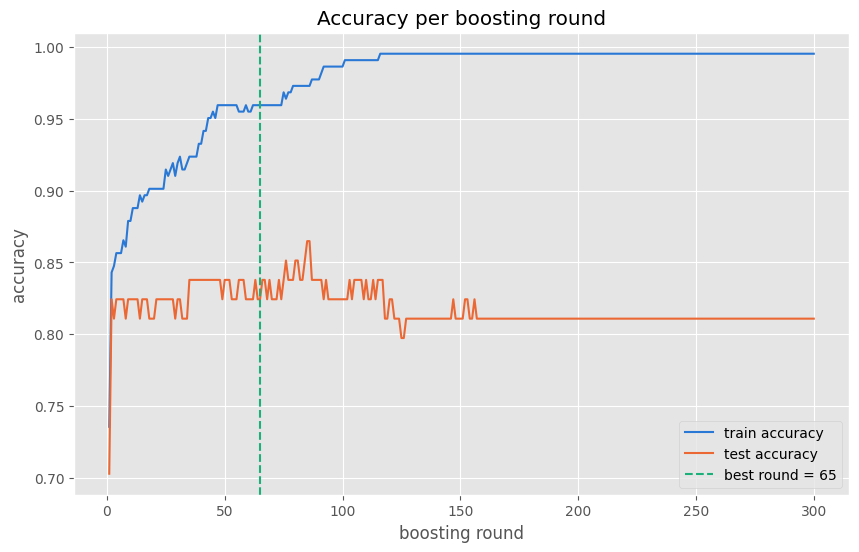

max train accuracy: 0.9955 at round 116
max test accuracy : 0.8649 at round 85
test accuracy at best_round 65 : 0.8243


In [9]:
plt.figure(figsize=(10, 6))
plt.plot(rounds, model.train_acc, color=BLUE, label='train accuracy')
plt.plot(rounds, model.test_acc, color=ORANGE, label='test accuracy')
plt.axvline(best_round, color=AQUA, linestyle='--',
            label=f'best round = {best_round}')
plt.title('Accuracy per boosting round')
plt.xlabel('boosting round')
plt.ylabel('accuracy')
plt.legend()
plt.show()

print('max train accuracy:', round(model.train_acc.max(), 4),
      'at round', int(np.argmax(model.train_acc)) + 1)
print('max test accuracy :', round(model.test_acc.max(), 4),
      'at round', int(np.argmax(model.test_acc)) + 1)
print('test accuracy at best_round', best_round, ':',
      round(model.test_acc[best_round - 1], 4))

## Baselines

Two comparisons, both self-contained.

The **majority-class baseline** always predicts whichever class is more common in the test set - the
floor any classifier has to beat.

The **single tree** is the same `Regression_Tree` machinery run for exactly one boosting round with
$\eta = 1$, so the ensemble is $F_0$ plus one full-strength tree and nothing else. That isolates
what one tree can do from what the sequence of them does. Depths 3 and 5 are both tried, since a
single tree is normally allowed to be deeper than a boosted one.

In [10]:
majority = max(y_test.mean(), 1 - y_test.mean())
print('majority-class baseline accuracy:', round(majority, 4))
print()

for depth in [3, 5]:
    single = XGBoost(n_rounds=1, learning_rate=1.0, max_depth=depth,
                     lambda_=1.0, gamma=0.05, min_child_weight=1.0)
    single.fit(X_train, y_train, X_test, y_test)
    print(f'single tree, depth {depth}: test accuracy',
          round(single.test_acc[-1], 4),
          ' test log loss', round(single.test_loss[-1], 4),
          ' splits', single.nodes_split)

print()
print('boosted ensemble at round', best_round, ': test accuracy',
      round(model.test_acc[best_round - 1], 4),
      ' test log loss', round(model.test_loss[best_round - 1], 4))

majority-class baseline accuracy: 0.5676

single tree, depth 3: test accuracy 0.8108  test log loss 0.4437  splits 7
single tree, depth 5: test accuracy 0.7973  test log loss 0.4387  splits 14

boosted ensemble at round 65 : test accuracy 0.8243  test log loss 0.3641


## The effect of the learning rate

The cell refits the model at $\eta \in \{0.5, 0.3, 0.1, 0.05\}$, holding everything else fixed, and
plots the four test-loss curves on the same axes with a marker at each one's minimum.

$\eta$ scales every tree's contribution in $F_t = F_{t-1} + \eta f_t$. Large $\eta$ takes big steps,
so the curve drops almost immediately and then turns upward early - each tree is fitted to the
residuals left by a coarse, over-committed previous step. Small $\eta$ takes many small steps, so the
curve descends slowly and the minimum arrives much later. The number of rounds needed scales roughly
inversely with $\eta$.

Two things to read honestly off the printed table. The clear effect is on the **right-hand end**:
after 300 rounds the loss is far worse for large $\eta$ than for small, so a small learning rate
degrades much more slowly once past its minimum, which makes the choice of stopping round less
critical. The effect on the **depth of the minimum** is much weaker here - $\eta = 0.5$ is plainly
the worst, but between 0.3, 0.1 and 0.05 the best losses differ by under 0.01, which on a 74-row
test set is noise. The textbook claim that smaller $\eta$ always reaches a better minimum is not
supported by this data; only the claim that too-large $\eta$ hurts is.

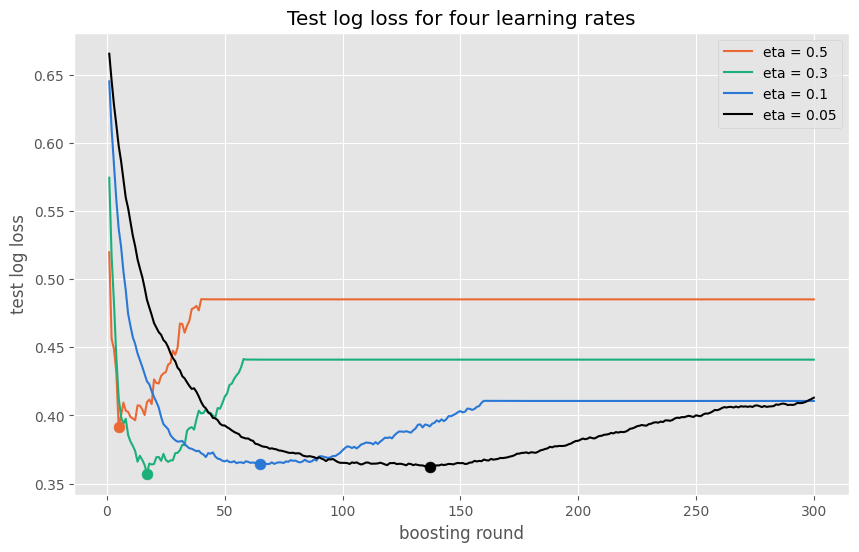

   eta  best round  best loss  acc there  loss @300
   0.5           5     0.3915     0.8108     0.4853
   0.3          17     0.3572     0.8378     0.4410
   0.1          65     0.3641     0.8243     0.4107
  0.05         137     0.3622     0.8243     0.4131


In [11]:
lr_values = [0.5, 0.3, 0.1, 0.05]
lr_colors = [ORANGE, AQUA, BLUE, 'k']
lr_results = []

plt.figure(figsize=(10, 6))
for eta, colour in zip(lr_values, lr_colors):
    m = XGBoost(n_rounds=300, learning_rate=eta, max_depth=3,
                lambda_=1.0, gamma=0.05, min_child_weight=1.0)
    m.fit(X_train, y_train, X_test, y_test)

    k = int(np.argmin(m.test_loss))
    lr_results.append((eta, k + 1, m.test_loss[k], m.test_acc[k], m.test_loss[-1]))

    plt.plot(rounds, m.test_loss, color=colour, label=f'eta = {eta}')
    plt.scatter([k + 1], [m.test_loss[k]], color=colour, s=60, zorder=5)

plt.title('Test log loss for four learning rates')
plt.xlabel('boosting round')
plt.ylabel('test log loss')
plt.legend()
plt.show()

print(f"{'eta':>6} {'best round':>11} {'best loss':>10} {'acc there':>10} {'loss @300':>10}")
for eta, br, bl, ba, fl in lr_results:
    print(f'{eta:>6} {br:>11} {bl:>10.4f} {ba:>10.4f} {fl:>10.4f}')

## The effect of $\lambda$ and $\gamma$

The two regularisers act in different places, so the cell sweeps them separately and records both
the best test loss reached and the total number of splits taken across all 200 trees.

$\lambda$ sits in the denominator of $w_j^* = -G_j / (H_j + \lambda)$, shrinking every leaf value
towards zero. Its main effect is therefore on step size: each round moves the prediction less, and
the best round moves later - from round 70 at $\lambda = 0$ out to round 179 at $\lambda = 20$. It
does not forbid splits, but it is not neutral on tree shape either, since it appears in the gain
formula as well; the split count rises with it, because shrunken leaves leave more residual for the
next split to work on.

$\gamma$ is subtracted directly from the gain, so it changes which splits happen at all. Every
candidate split has to be worth at least $\gamma$ to be taken, and a node whose best available split
is not is left as a leaf. This is the visible one: the split count collapses from 1137 to 158 across
the sweep, and the best round arrives earlier because each tree does less. Test loss dips slightly
and then worsens as the trees get too small to fit anything, though the swing is small in absolute
terms.

The four panels show test loss and split count for each sweep.

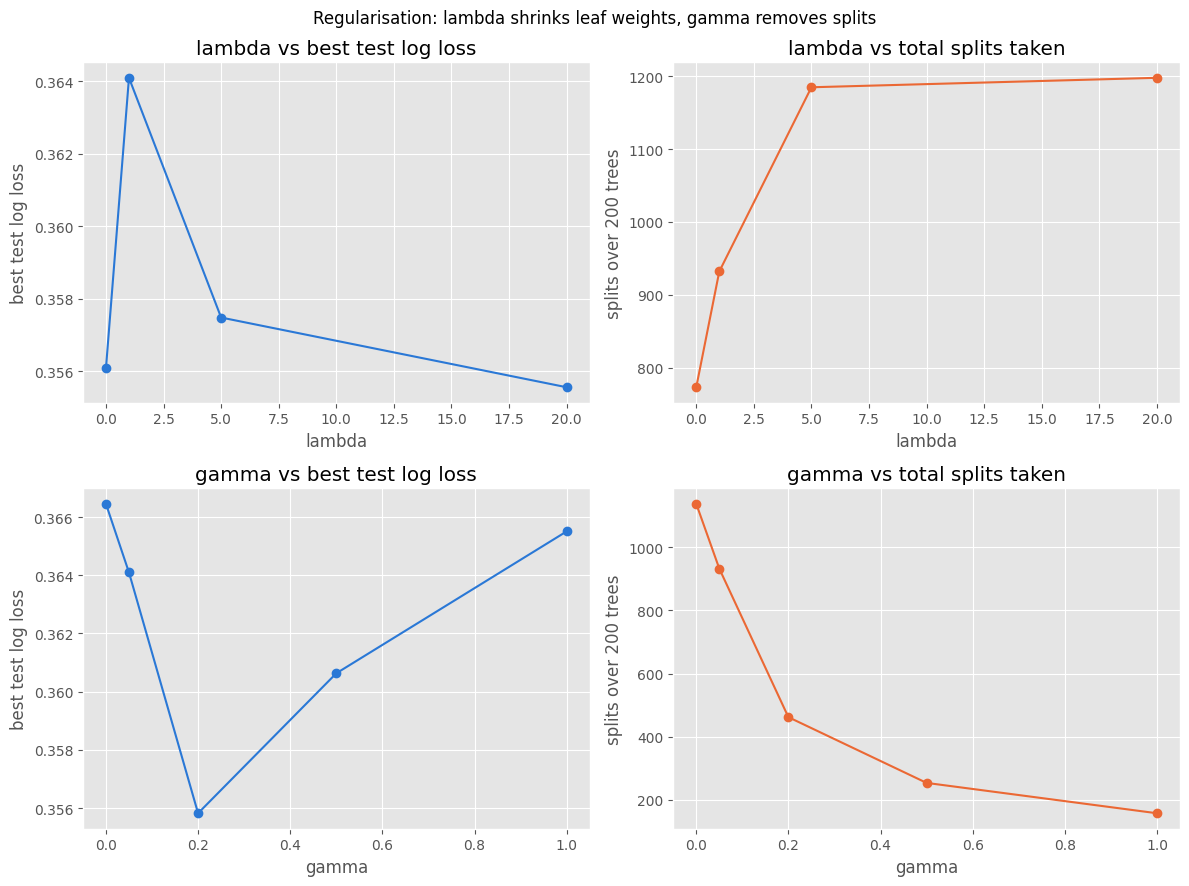

 lambda  best loss  best round   splits
    0.0     0.3561          70      773
    1.0     0.3641          65      932
    5.0     0.3575          94     1185
   20.0     0.3556         179     1198

  gamma  best loss  best round   splits  cands rejected
    0.0     0.3665          60     1137               0
   0.05     0.3641          65      932           73395
    0.2     0.3558          57      462           77039
    0.5     0.3606          46      254           72504
    1.0     0.3655          33      158           72590


In [12]:
lam_values = [0.0, 1.0, 5.0, 20.0]
gam_values = [0.0, 0.05, 0.2, 0.5, 1.0]

lam_loss, lam_splits, lam_round = [], [], []
for lam in lam_values:
    m = XGBoost(n_rounds=200, learning_rate=0.1, max_depth=3,
                lambda_=lam, gamma=0.05, min_child_weight=1.0)
    m.fit(X_train, y_train, X_test, y_test)
    lam_loss.append(m.test_loss.min())
    lam_splits.append(m.nodes_split)
    lam_round.append(int(np.argmin(m.test_loss)) + 1)

gam_loss, gam_splits, gam_round, gam_rejected = [], [], [], []
for gam in gam_values:
    m = XGBoost(n_rounds=200, learning_rate=0.1, max_depth=3,
                lambda_=1.0, gamma=gam, min_child_weight=1.0)
    m.fit(X_train, y_train, X_test, y_test)
    gam_loss.append(m.test_loss.min())
    gam_splits.append(m.nodes_split)
    gam_round.append(int(np.argmin(m.test_loss)) + 1)
    gam_rejected.append(m.n_gamma_rejected)

fig, ax = plt.subplots(2, 2, figsize=(12, 9))

ax[0, 0].plot(lam_values, lam_loss, 'o-', color=BLUE)
ax[0, 0].set_title('lambda vs best test log loss')
ax[0, 0].set_xlabel('lambda')
ax[0, 0].set_ylabel('best test log loss')

ax[0, 1].plot(lam_values, lam_splits, 'o-', color=ORANGE)
ax[0, 1].set_title('lambda vs total splits taken')
ax[0, 1].set_xlabel('lambda')
ax[0, 1].set_ylabel('splits over 200 trees')

ax[1, 0].plot(gam_values, gam_loss, 'o-', color=BLUE)
ax[1, 0].set_title('gamma vs best test log loss')
ax[1, 0].set_xlabel('gamma')
ax[1, 0].set_ylabel('best test log loss')

ax[1, 1].plot(gam_values, gam_splits, 'o-', color=ORANGE)
ax[1, 1].set_title('gamma vs total splits taken')
ax[1, 1].set_xlabel('gamma')
ax[1, 1].set_ylabel('splits over 200 trees')

fig.suptitle('Regularisation: lambda shrinks leaf weights, gamma removes splits')
fig.tight_layout()
plt.show()

print(f"{'lambda':>7} {'best loss':>10} {'best round':>11} {'splits':>8}")
for v, l, r, s in zip(lam_values, lam_loss, lam_round, lam_splits):
    print(f'{v:>7} {l:>10.4f} {r:>11} {s:>8}')
print()
print(f"{'gamma':>7} {'best loss':>10} {'best round':>11} {'splits':>8} {'cands rejected':>15}")
for v, l, r, s, j in zip(gam_values, gam_loss, gam_round, gam_splits, gam_rejected):
    print(f'{v:>7} {l:>10.4f} {r:>11} {s:>8} {j:>15}')

## Pruning, counted

The cell reports the counters accumulated during the main fit. Every candidate threshold on every
feature at every node was scored, and each one fell into exactly one of these outcomes:

- **negative raw gain** - the split made the objective worse before $\gamma$ was even charged. These
  exist only because $\lambda > 0$; with $\lambda = 0$ the bracketed gain term cannot go below zero.
- **rejected by $\gamma$** - the raw gain was positive but did not clear the $\gamma$ price of the
  extra leaf, so the split was not worth paying for.
- **rejected by `min_child_weight`** - a child's summed hessian was too small.

`nodes_stopped_by_gamma` counts nodes that had a genuinely positive best split available and were
still left as leaves because $\gamma$ ate it. Those are the nodes where pruning actually changed the
shape of a tree.

In [13]:
total = model.n_candidates
taken = model.nodes_split

print('main model: n_rounds=300, eta=0.1, max_depth=3, lambda=1.0, gamma=0.05')
print()
print('candidate splits scored          :', total)
print('  negative raw gain (lambda)     :', model.n_negative_gain,
      f'({100 * model.n_negative_gain / total:.1f}%)')
print('  rejected by gamma              :', model.n_gamma_rejected,
      f'({100 * model.n_gamma_rejected / total:.1f}%)')
print('  rejected by min_child_weight   :', model.n_child_weight_rejected,
      f'({100 * model.n_child_weight_rejected / total:.1f}%)')
print()
print('splits actually taken            :', taken)
print('nodes left as leaves by gamma    :', model.nodes_stopped_by_gamma)
print('average splits per tree          :', round(taken / len(model.trees), 2),
      'out of a possible 7 at depth 3')

main model: n_rounds=300, eta=0.1, max_depth=3, lambda=1.0, gamma=0.05

candidate splits scored          : 277616
  negative raw gain (lambda)     : 32242 (11.6%)
  rejected by gamma              : 98795 (35.6%)
  rejected by min_child_weight   : 89485 (32.2%)

splits actually taken            : 932
nodes left as leaves by gamma    : 157
average splits per tree          : 3.11 out of a possible 7 at depth 3


## Feature importance by total gain

Every time a split is taken, its gain is added to the score of the feature it split on. Summing that
over all 300 trees gives a total-gain importance: how much objective improvement each feature was
responsible for across the whole ensemble.

Features never split on score zero. This is a measure of contribution to the fit, not of a causal
effect, and correlated features will share credit arbitrarily depending on which one happened to be
picked first.

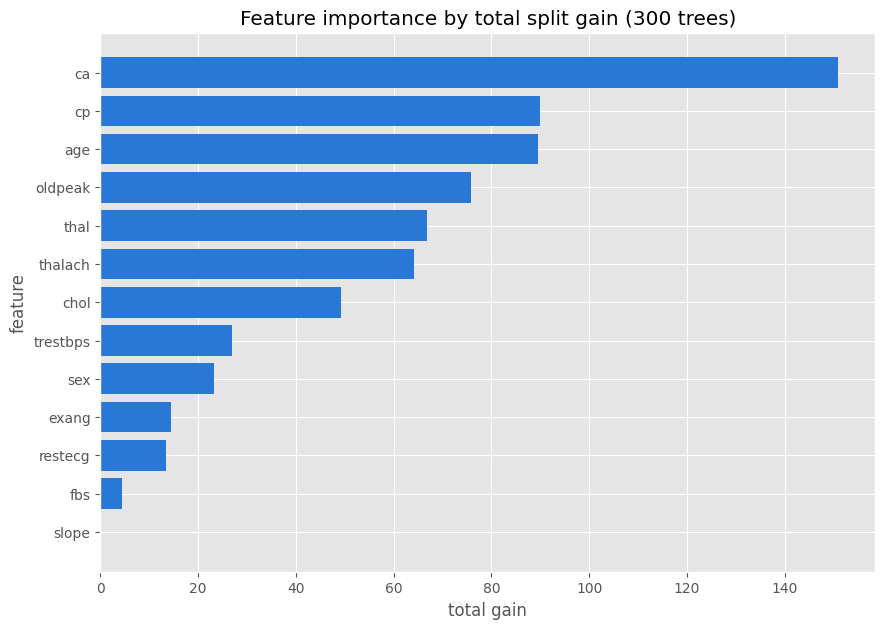

   feature   total gain    share
        ca       150.97    22.5%
        cp        90.01    13.4%
       age        89.59    13.4%
   oldpeak        75.87    11.3%
      thal        66.82    10.0%
   thalach        64.26     9.6%
      chol        49.26     7.4%
  trestbps        27.01     4.0%
       sex        23.27     3.5%
     exang        14.57     2.2%
   restecg        13.37     2.0%
       fbs         4.54     0.7%
     slope         0.07     0.0%


In [14]:
order = np.argsort(model.gain_by_feature)
names_sorted = [feature_names[j] for j in order]
gains_sorted = model.gain_by_feature[order]

plt.figure(figsize=(10, 7))
plt.barh(names_sorted, gains_sorted, color=BLUE)
plt.title('Feature importance by total split gain (300 trees)')
plt.xlabel('total gain')
plt.ylabel('feature')
plt.show()

print(f"{'feature':>10} {'total gain':>12} {'share':>8}")
for j in order[::-1]:
    print(f'{feature_names[j]:>10} {model.gain_by_feature[j]:>12.2f}'
          f' {100 * model.gain_by_feature[j] / model.gain_by_feature.sum():>7.1f}%')

## Confusion matrix at the best round

`predict` is called with `n_rounds=best_round`, so the ensemble is truncated to the trees fitted
before test loss started rising. The matrix is built with two nested comparisons and drawn with
`imshow`, counts annotated in each cell.

Rows are the true label, columns the prediction. The off-diagonal entries are the two error types:
a false negative is a patient with disease predicted as healthy, which on this dataset is the more
costly mistake.

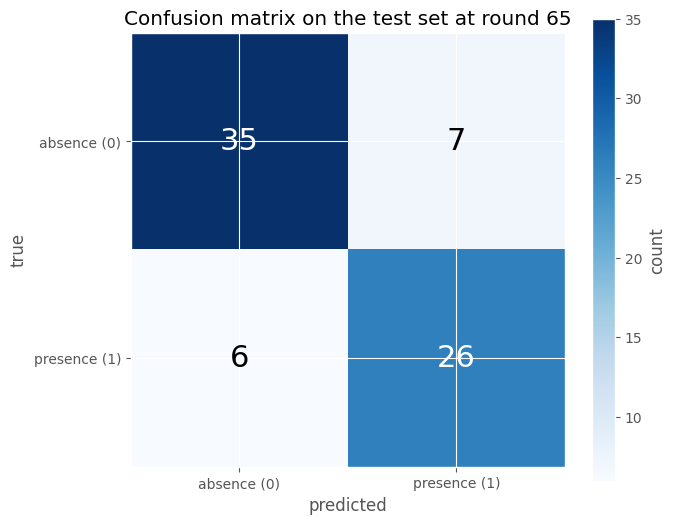

true negatives : 35   false positives: 7
false negatives: 6   true positives : 26

accuracy : 0.8243
precision: 0.7879
recall   : 0.8125


In [15]:
pred = model.predict(X_test, n_rounds=best_round)

cm = np.zeros((2, 2), dtype=int)
for a in [0, 1]:
    for b in [0, 1]:
        cm[a, b] = int(((y_test == a) & (pred == b)).sum())

labels = ['absence (0)', 'presence (1)']

plt.figure(figsize=(7, 6))
plt.imshow(cm, cmap='Blues')
plt.colorbar(label='count')
plt.xticks([0, 1], labels)
plt.yticks([0, 1], labels)
for a in [0, 1]:
    for b in [0, 1]:
        plt.text(b, a, cm[a, b], ha='center', va='center', fontsize=22,
                 color='white' if cm[a, b] > cm.max() / 2 else 'black')
plt.title(f'Confusion matrix on the test set at round {best_round}')
plt.xlabel('predicted')
plt.ylabel('true')
plt.show()

tn, fp, fn, tp = cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]
print('true negatives :', tn, '  false positives:', fp)
print('false negatives:', fn, '  true positives :', tp)
print()
print('accuracy :', round((tn + tp) / cm.sum(), 4))
print('precision:', round(tp / (tp + fp), 4))
print('recall   :', round(tp / (tp + fn), 4))

## What the fitted object actually contains

`show_tree` walks the first tree recursively and prints its structure: at each internal node the
feature, threshold, gain and number of points, and at each leaf the weight $w_j^*$ and its point
count. The first tree is fitted at $F = F_0$, where every point has $p$ equal to the base rate, so
its gradients are the largest of the run and its splits are the clearest.

The histogram then shows every leaf weight in the whole ensemble. The weights are small, which is
the point: each tree only nudges the log-odds by $\eta w_j$, and it is the sum of 300 such nudges
that produces the fit. It also shows the effect of $\lambda$, which pulls every one of these values
towards zero.

first tree:
[ca <= 0.50]   gain = 28.384   n = 223
  [thal <= 6.50]   gain = 8.190   n = 132
    [oldpeak <= 2.70]   gain = 3.145   n = 93
      leaf  w = -1.4096   n = 87
      leaf  w = +0.4709   n = 6
    [cp <= 3.50]   gain = 3.797   n = 39
      leaf  w = -0.5711   n = 20
      leaf  w = +1.0558   n = 19
  [cp <= 3.50]   gain = 7.359   n = 91
    [oldpeak <= 0.35]   gain = 2.829   n = 31
      leaf  w = -0.7087   n = 16
      leaf  w = +0.8311   n = 15
    [age <= 63.50]   gain = 0.186   n = 60
      leaf  w = +1.8828   n = 48
      leaf  w = +0.8396   n = 12


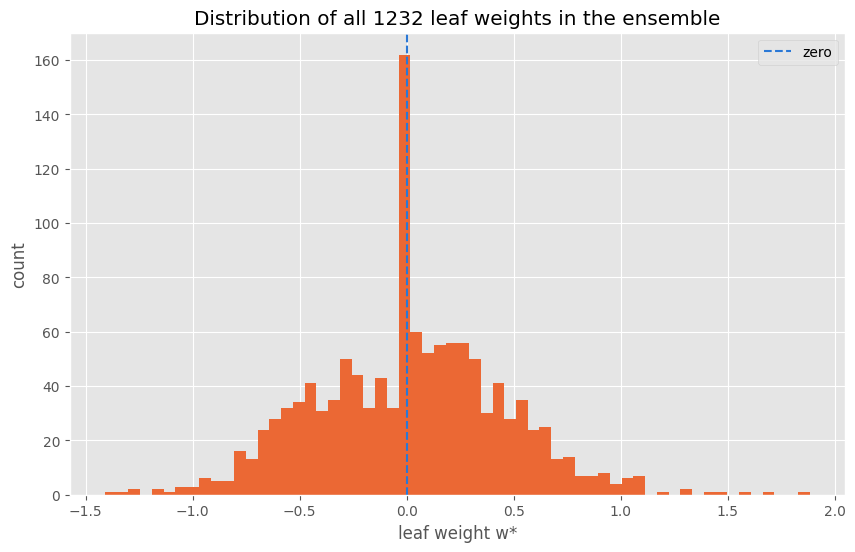

leaves in total : 1232
mean weight     : 0.0163
min / max weight: -1.4096 / 1.8828


In [16]:
def show_tree(node, depth=0):
    pad = '  ' * depth
    if node['leaf']:
        print(f"{pad}leaf  w = {node['weight']:+.4f}   n = {node['n']}")
    else:
        print(f"{pad}[{feature_names[node['feature']]} <= {node['threshold']:.2f}]"
              f"   gain = {node['gain']:.3f}   n = {node['n']}")
        show_tree(node['left'], depth + 1)
        show_tree(node['right'], depth + 1)


print('first tree:')
show_tree(model.trees[0].root)


def leaf_weights(node, out):
    if node['leaf']:
        out.append(node['weight'])
    else:
        leaf_weights(node['left'], out)
        leaf_weights(node['right'], out)
    return out


all_weights = []
for tree in model.trees:
    leaf_weights(tree.root, all_weights)
all_weights = np.array(all_weights)

plt.figure(figsize=(10, 6))
plt.hist(all_weights, bins=60, color=ORANGE)
plt.axvline(0, color=BLUE, linestyle='--', label='zero')
plt.title(f'Distribution of all {len(all_weights)} leaf weights in the ensemble')
plt.xlabel('leaf weight w*')
plt.ylabel('count')
plt.legend()
plt.show()

print('leaves in total :', len(all_weights))
print('mean weight     :', round(all_weights.mean(), 4))
print('min / max weight:', round(all_weights.min(), 4), '/', round(all_weights.max(), 4))

## Summary

The implementation is the XGBoost formulation rather than plain gradient boosting: leaf values come
from the closed-form $w_j^* = -G_j/(H_j + \lambda)$ derived by setting $\partial \mathcal{L}/\partial w_j = 0$
on the second-order expansion, splits are chosen by the gain formula built from the same expansion,
and $\gamma$ prunes splits that do not pay for the leaf they add. All of it is second-order - the
hessians $h_i = p_i(1-p_i)$ appear in every one of those formulas and are what makes the leaf value
a Newton step rather than a plain average of residuals.

On this dataset the result is modest. 297 rows and 13 features is a small problem, the test set is
74 rows, and one flipped prediction moves accuracy by 1.4 points, so the differences between
reasonable hyperparameter settings are inside the noise - the learning rate and $\lambda$ sweeps
above both show best losses separated by less than 0.01. Against a single depth-3 tree the ensemble
gains a little accuracy and a lot of log loss, which is the honest shape of the improvement: it is
much better calibrated rather than much more often right.

The clearest result is the overfitting curve. Training loss falls towards zero without stopping
while test loss reaches a minimum and then climbs, and that gap is entirely a product of the
sequential construction. A random forest averaging independent trees has no mechanism to do this -
its errors are uncorrelated and averaging only ever helps. Boosting's trees are deliberately
correlated, each one fitted to what the last left behind, and once the real signal is used up the
thing they are correcting is noise.